# Phase 7-2: 커스텀 평가셋 구축
> "평가셋은 모델보다 오래 살아남는다. 좋은 평가셋 하나가 100번의 학습보다 가치 있다."

## 학습 목표
1. 커스텀 평가셋 설계 원칙을 이해한다
2. Text-to-SQL 평가셋 100개를 직접 구축한다
3. Exact Match + SQL 실행 정확도를 측정한다
4. BLEU / ROUGE / BERTScore를 비교한다
5. LLM-as-Judge 평가를 구현한다
6. 통합 평가 함수 evaluate_model()을 완성한다

In [ ]:
# 평가 메트릭 라이브러리 설치
# !pip install rouge-score bert-score nltk datasets transformers torch sacrebleu -q

In [6]:
import torch
import json
import re
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional
from datetime import datetime

# 설치된 한글 폰트 찾기
import matplotlib.font_manager as fm
[f.name for f in fm.fontManager.ttflist if 'Gothic' in f.name or 'Malgun' in f.name]

# GPU 확인
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    print(f"GPU: {gpu.name} ({gpu.total_memory // 1024**3}GB)")
else:
    print("CPU 모드")

print(f"실행 시각: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

GPU: NVIDIA GeForce RTX 4070 Ti (11GB)
실행 시각: 2026-03-16 16:47


## 1. 평가셋 설계 원칙

### 좋은 평가셋의 조건
| 원칙 | 설명 | 나쁜 예 |
|------|------|--------|
| **대표성** | 실제 사용 패턴 반영 | 쉬운 것만 100개 |
| **난이도 분포** | Easy 40% / Medium 40% / Hard 20% | 모두 같은 난이도 |
| **다양성** | 다양한 패턴/유형 포함 | SELECT만 100개 |
| **비오염** | 학습 데이터와 겹치지 않음 | 학습셋에서 복사 |
| **검증 가능** | 정답을 자동 검증 가능 | 주관적 정답만 |

### 적정 규모
- **최소**: 50개 (경향만 파악)
- **권장**: 100-200개 (통계적 의미)
- **이상적**: 500개+ (세분화 분석 가능)

### Contamination 방지
학습 데이터에 평가셋이 포함되면 평가 의미가 없다:
- 학습/평가 분리 시점을 명확히 기록
- 평가셋은 별도 파일로 관리 (학습 파이프라인에 포함 금지)
- Hash 기반 중복 검사

In [8]:
# import 다음에 추가
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 기호 깨짐 방지

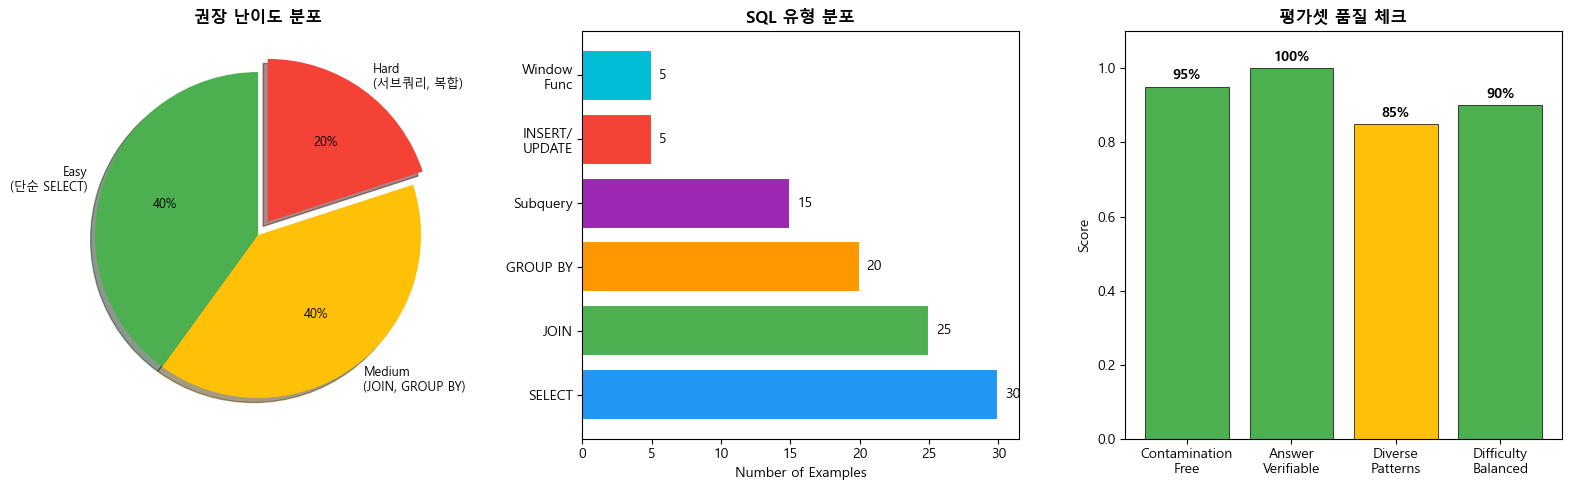

In [9]:
# 평가셋 설계 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: 난이도 분포
labels = ['Easy\n(단순 SELECT)', 'Medium\n(JOIN, GROUP BY)', 'Hard\n(서브쿼리, 복합)']
sizes = [40, 40, 20]
colors = ['#4CAF50', '#FFC107', '#F44336']
explode = (0, 0, 0.1)
axes[0].pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.0f%%',
            shadow=True, startangle=90, textprops={'fontsize': 9})
axes[0].set_title('권장 난이도 분포', fontsize=12, fontweight='bold')

# Panel 2: SQL 유형 분포
types = ['SELECT', 'JOIN', 'GROUP BY', 'Subquery', 'INSERT/\nUPDATE', 'Window\nFunc']
counts = [30, 25, 20, 15, 5, 5]
colors2 = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336', '#00BCD4']
bars = axes[1].barh(types, counts, color=colors2, edgecolor='white', linewidth=1.5)
axes[1].set_xlabel('Number of Examples')
axes[1].set_title('SQL 유형 분포', fontsize=12, fontweight='bold')
for bar, count in zip(bars, counts):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{count}', va='center', fontsize=10)

# Panel 3: Quality metrics
metrics = ['Contamination\nFree', 'Answer\nVerifiable', 'Diverse\nPatterns', 'Difficulty\nBalanced']
scores = [0.95, 1.0, 0.85, 0.90]
colors3 = ['#4CAF50' if s >= 0.9 else '#FFC107' for s in scores]
bars3 = axes[2].bar(metrics, scores, color=colors3, edgecolor='black', linewidth=0.5)
axes[2].set_ylim(0, 1.1)
axes[2].set_ylabel('Score')
axes[2].set_title('평가셋 품질 체크', fontsize=12, fontweight='bold')
for bar, score in zip(bars3, scores):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{score:.0%}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 2. Text-to-SQL 평가셋 구축 (100개)

Phase 4에서 학습한 Text-to-SQL 모델을 평가하기 위한 커스텀 평가셋을 구축한다.

### 데이터베이스 스키마 (평가용)
```sql
CREATE TABLE employees (id, name, department, salary, hire_date, manager_id);
CREATE TABLE departments (id, name, budget, location);
CREATE TABLE projects (id, name, department_id, start_date, end_date, status);
CREATE TABLE assignments (employee_id, project_id, role, hours);
```

In [10]:
# ============================================================
# Text-to-SQL 평가셋 100개 구축
# ============================================================

# 데이터베이스 스키마 정의
DB_SCHEMA = """
CREATE TABLE employees (
    id INTEGER PRIMARY KEY,
    name TEXT,
    department TEXT,
    salary REAL,
    hire_date TEXT,
    manager_id INTEGER
);

CREATE TABLE departments (
    id INTEGER PRIMARY KEY,
    name TEXT,
    budget REAL,
    location TEXT
);

CREATE TABLE projects (
    id INTEGER PRIMARY KEY,
    name TEXT,
    department_id INTEGER,
    start_date TEXT,
    end_date TEXT,
    status TEXT
);

CREATE TABLE assignments (
    employee_id INTEGER,
    project_id INTEGER,
    role TEXT,
    hours REAL
);
"""

# 평가셋 구축
eval_dataset = []

# === Easy (40개): 단순 SELECT, WHERE, ORDER BY ===
easy_examples = [
    ("직원 테이블에서 모든 직원의 이름을 조회해줘", "SELECT name FROM employees"),
    ("급여가 50000 이상인 직원을 조회해줘", "SELECT * FROM employees WHERE salary >= 50000"),
    ("Engineering 부서의 직원 이름을 알려줘", "SELECT name FROM employees WHERE department = 'Engineering'"),
    ("직원을 급여 높은 순으로 정렬해줘", "SELECT * FROM employees ORDER BY salary DESC"),
    ("모든 부서의 이름과 예산을 조회해줘", "SELECT name, budget FROM departments"),
    ("진행 중인 프로젝트를 조회해줘", "SELECT * FROM projects WHERE status = 'active'"),
    ("서울에 위치한 부서를 찾아줘", "SELECT * FROM departments WHERE location = 'Seoul'"),
    ("급여가 30000에서 60000 사이인 직원을 조회해줘", "SELECT * FROM employees WHERE salary BETWEEN 30000 AND 60000"),
    ("2023년 이후 입사한 직원을 조회해줘", "SELECT * FROM employees WHERE hire_date >= '2023-01-01'"),
    ("직원 수를 알려줘", "SELECT COUNT(*) FROM employees"),
    ("가장 높은 급여를 알려줘", "SELECT MAX(salary) FROM employees"),
    ("가장 낮은 급여를 알려줘", "SELECT MIN(salary) FROM employees"),
    ("평균 급여를 알려줘", "SELECT AVG(salary) FROM employees"),
    ("급여 합계를 알려줘", "SELECT SUM(salary) FROM employees"),
    ("이름이 'Kim'인 직원을 찾아줘", "SELECT * FROM employees WHERE name = 'Kim'"),
    ("프로젝트 이름만 조회해줘", "SELECT name FROM projects"),
    ("예산이 가장 큰 부서를 알려줘", "SELECT * FROM departments ORDER BY budget DESC LIMIT 1"),
    ("직원 이름과 부서를 조회해줘", "SELECT name, department FROM employees"),
    ("완료된 프로젝트를 조회해줘", "SELECT * FROM projects WHERE status = 'completed'"),
    ("부서별 위치를 알려줘", "SELECT name, location FROM departments"),
    ("상위 5명의 고급여 직원을 알려줘", "SELECT * FROM employees ORDER BY salary DESC LIMIT 5"),
    ("직원 이름에 'Park'이 포함된 사람을 찾아줘", "SELECT * FROM employees WHERE name LIKE '%Park%'"),
    ("매니저가 없는 직원을 찾아줘", "SELECT * FROM employees WHERE manager_id IS NULL"),
    ("급여가 높은 순으로 상위 10명을 알려줘", "SELECT * FROM employees ORDER BY salary DESC LIMIT 10"),
    ("프로젝트 수를 알려줘", "SELECT COUNT(*) FROM projects"),
    ("부서 수를 알려줘", "SELECT COUNT(*) FROM departments"),
    ("2024년에 시작한 프로젝트를 조회해줘", "SELECT * FROM projects WHERE start_date >= '2024-01-01' AND start_date < '2025-01-01'"),
    ("급여가 100000 이상인 직원의 이름과 급여를 알려줘", "SELECT name, salary FROM employees WHERE salary >= 100000"),
    ("직원을 이름 순으로 정렬해줘", "SELECT * FROM employees ORDER BY name ASC"),
    ("가장 최근에 입사한 직원을 알려줘", "SELECT * FROM employees ORDER BY hire_date DESC LIMIT 1"),
    ("예산이 1000000 이상인 부서를 찾아줘", "SELECT * FROM departments WHERE budget >= 1000000"),
    ("프로젝트를 시작일 순으로 정렬해줘", "SELECT * FROM projects ORDER BY start_date ASC"),
    ("배정 시간이 가장 많은 직원을 찾아줘", "SELECT employee_id, SUM(hours) as total_hours FROM assignments GROUP BY employee_id ORDER BY total_hours DESC LIMIT 1"),
    ("Engineering 부서 직원 수를 알려줘", "SELECT COUNT(*) FROM employees WHERE department = 'Engineering'"),
    ("직원별 급여 등급을 매겨줘 (50000 이상 High, 이하 Low)", "SELECT name, CASE WHEN salary >= 50000 THEN 'High' ELSE 'Low' END as grade FROM employees"),
    ("이름과 급여를 조회하되 급여가 NULL인 건 제외해줘", "SELECT name, salary FROM employees WHERE salary IS NOT NULL"),
    ("부서 이름을 중복 없이 조회해줘", "SELECT DISTINCT department FROM employees"),
    ("프로젝트가 active이거나 pending인 것을 조회해줘", "SELECT * FROM projects WHERE status IN ('active', 'pending')"),
    ("직원 ID가 1, 2, 3인 직원을 조회해줘", "SELECT * FROM employees WHERE id IN (1, 2, 3)"),
    ("급여를 10% 인상한 결과를 보여줘", "SELECT name, salary, salary * 1.1 as new_salary FROM employees"),
]

for q, a in easy_examples:
    eval_dataset.append({"question": q, "sql": a, "difficulty": "easy"})

# === Medium (40개): JOIN, GROUP BY, HAVING, 집계 ===
medium_examples = [
    ("부서별 평균 급여를 알려줘", "SELECT department, AVG(salary) as avg_salary FROM employees GROUP BY department"),
    ("부서별 직원 수를 알려줘", "SELECT department, COUNT(*) as cnt FROM employees GROUP BY department"),
    ("직원과 그 직원이 속한 부서의 예산을 함께 조회해줘", "SELECT e.name, d.budget FROM employees e JOIN departments d ON e.department = d.name"),
    ("프로젝트와 해당 부서 이름을 함께 조회해줘", "SELECT p.name, d.name as dept_name FROM projects p JOIN departments d ON p.department_id = d.id"),
    ("부서별 평균 급여가 50000 이상인 부서를 알려줘", "SELECT department, AVG(salary) as avg_sal FROM employees GROUP BY department HAVING AVG(salary) >= 50000"),
    ("직원과 배정된 프로젝트를 함께 조회해줘", "SELECT e.name, p.name as project FROM employees e JOIN assignments a ON e.id = a.employee_id JOIN projects p ON a.project_id = p.id"),
    ("프로젝트별 배정된 직원 수를 알려줘", "SELECT p.name, COUNT(a.employee_id) as cnt FROM projects p JOIN assignments a ON p.id = a.project_id GROUP BY p.name"),
    ("부서별 최고 급여를 알려줘", "SELECT department, MAX(salary) as max_sal FROM employees GROUP BY department"),
    ("직원별 총 배정 시간을 알려줘", "SELECT e.name, SUM(a.hours) as total FROM employees e JOIN assignments a ON e.id = a.employee_id GROUP BY e.name"),
    ("3개 이상의 프로젝트에 배정된 직원을 찾아줘", "SELECT e.name, COUNT(a.project_id) as proj_cnt FROM employees e JOIN assignments a ON e.id = a.employee_id GROUP BY e.name HAVING COUNT(a.project_id) >= 3"),
    ("부서별 급여 합계가 큰 순으로 정렬해줘", "SELECT department, SUM(salary) as total FROM employees GROUP BY department ORDER BY total DESC"),
    ("각 프로젝트의 총 작업 시간을 알려줘", "SELECT p.name, SUM(a.hours) as total_hours FROM projects p JOIN assignments a ON p.id = a.project_id GROUP BY p.name"),
    ("매니저가 있는 직원과 매니저 이름을 함께 조회해줘", "SELECT e.name as employee, m.name as manager FROM employees e JOIN employees m ON e.manager_id = m.id"),
    ("부서와 그 부서의 프로젝트 수를 알려줘", "SELECT d.name, COUNT(p.id) as proj_cnt FROM departments d LEFT JOIN projects p ON d.id = p.department_id GROUP BY d.name"),
    ("활성 프로젝트에 배정된 직원 이름을 알려줘", "SELECT DISTINCT e.name FROM employees e JOIN assignments a ON e.id = a.employee_id JOIN projects p ON a.project_id = p.id WHERE p.status = 'active'"),
    ("급여가 부서 평균보다 높은 직원을 찾아줘", "SELECT e.name, e.salary, e.department FROM employees e JOIN (SELECT department, AVG(salary) as avg_sal FROM employees GROUP BY department) d ON e.department = d.department WHERE e.salary > d.avg_sal"),
    ("직원이 5명 이상인 부서만 조회해줘", "SELECT department, COUNT(*) as cnt FROM employees GROUP BY department HAVING COUNT(*) >= 5"),
    ("배정되지 않은 직원을 찾아줘", "SELECT e.name FROM employees e LEFT JOIN assignments a ON e.id = a.employee_id WHERE a.employee_id IS NULL"),
    ("부서별 급여 중앙값 대신 평균과 최소, 최대를 알려줘", "SELECT department, AVG(salary) as avg_sal, MIN(salary) as min_sal, MAX(salary) as max_sal FROM employees GROUP BY department"),
    ("프로젝트가 없는 부서를 찾아줘", "SELECT d.name FROM departments d LEFT JOIN projects p ON d.id = p.department_id WHERE p.id IS NULL"),
    ("각 역할별 평균 배정 시간을 알려줘", "SELECT role, AVG(hours) as avg_hours FROM assignments GROUP BY role"),
    ("서울 부서의 직원 이름과 급여를 조회해줘", "SELECT e.name, e.salary FROM employees e JOIN departments d ON e.department = d.name WHERE d.location = 'Seoul'"),
    ("프로젝트별 lead 역할 직원을 조회해줘", "SELECT p.name, e.name as lead FROM projects p JOIN assignments a ON p.id = a.project_id JOIN employees e ON a.employee_id = e.id WHERE a.role = 'lead'"),
    ("부서별 2023년 이후 입사자 수를 알려줘", "SELECT department, COUNT(*) as cnt FROM employees WHERE hire_date >= '2023-01-01' GROUP BY department"),
    ("직원 수가 가장 많은 부서 Top 3를 알려줘", "SELECT department, COUNT(*) as cnt FROM employees GROUP BY department ORDER BY cnt DESC LIMIT 3"),
    ("프로젝트 기간(일수)을 계산해줘", "SELECT name, JULIANDAY(end_date) - JULIANDAY(start_date) as duration_days FROM projects"),
    ("완료된 프로젝트의 부서별 수를 알려줘", "SELECT d.name, COUNT(p.id) as completed FROM departments d JOIN projects p ON d.id = p.department_id WHERE p.status = 'completed' GROUP BY d.name"),
    ("급여 상위 10%에 해당하는 직원을 찾아줘", "SELECT * FROM employees WHERE salary >= (SELECT salary FROM employees ORDER BY salary DESC LIMIT 1 OFFSET (SELECT COUNT(*) / 10 FROM employees))"),
    ("부서별 입사일이 가장 오래된 직원을 찾아줘", "SELECT department, name, hire_date FROM employees e WHERE hire_date = (SELECT MIN(hire_date) FROM employees WHERE department = e.department)"),
    ("전체 직원의 급여 표준편차와 평균을 알려줘", "SELECT AVG(salary) as avg_sal, AVG(salary * salary) - AVG(salary) * AVG(salary) as variance FROM employees"),
    ("각 위치별 부서 수와 총 예산을 알려줘", "SELECT location, COUNT(*) as dept_cnt, SUM(budget) as total_budget FROM departments GROUP BY location"),
    ("프로젝트에 가장 많은 시간을 투입한 직원 Top 5를 알려줘", "SELECT e.name, SUM(a.hours) as total FROM employees e JOIN assignments a ON e.id = a.employee_id GROUP BY e.name ORDER BY total DESC LIMIT 5"),
    ("같은 매니저를 가진 직원들을 그룹으로 보여줘", "SELECT manager_id, GROUP_CONCAT(name) as team_members FROM employees WHERE manager_id IS NOT NULL GROUP BY manager_id"),
    ("부서별 급여 범위(최대-최소)를 알려줘", "SELECT department, MAX(salary) - MIN(salary) as salary_range FROM employees GROUP BY department"),
    ("연도별 입사자 수를 알려줘", "SELECT SUBSTR(hire_date, 1, 4) as year, COUNT(*) as cnt FROM employees GROUP BY year ORDER BY year"),
    ("활성 프로젝트가 2개 이상인 부서를 알려줘", "SELECT d.name, COUNT(p.id) as active_cnt FROM departments d JOIN projects p ON d.id = p.department_id WHERE p.status = 'active' GROUP BY d.name HAVING COUNT(p.id) >= 2"),
    ("각 직원의 프로젝트 참여 수와 평균 시간을 알려줘", "SELECT e.name, COUNT(a.project_id) as proj_cnt, AVG(a.hours) as avg_hours FROM employees e JOIN assignments a ON e.id = a.employee_id GROUP BY e.name"),
    ("부서 예산 대비 급여 총액 비율을 알려줘", "SELECT d.name, SUM(e.salary) as total_sal, d.budget, ROUND(SUM(e.salary) * 100.0 / d.budget, 1) as ratio FROM departments d JOIN employees e ON d.name = e.department GROUP BY d.name"),
    ("lead 역할 직원의 평균 급여를 알려줘", "SELECT AVG(e.salary) as avg_lead_salary FROM employees e JOIN assignments a ON e.id = a.employee_id WHERE a.role = 'lead'"),
    ("부서별 직원 목록을 한 줄로 보여줘", "SELECT department, GROUP_CONCAT(name, ', ') as members FROM employees GROUP BY department"),
]

for q, a in medium_examples:
    eval_dataset.append({"question": q, "sql": a, "difficulty": "medium"})

# === Hard (20개): 서브쿼리, CTE, 복합 조건 ===
hard_examples = [
    ("부서 평균보다 급여가 높은 직원의 이름, 급여, 부서 평균을 알려줘", 
     "SELECT e.name, e.salary, d.avg_sal FROM employees e JOIN (SELECT department, AVG(salary) as avg_sal FROM employees GROUP BY department) d ON e.department = d.department WHERE e.salary > d.avg_sal"),
    ("모든 프로젝트에 참여한 직원을 찾아줘",
     "SELECT e.name FROM employees e WHERE NOT EXISTS (SELECT p.id FROM projects p WHERE NOT EXISTS (SELECT 1 FROM assignments a WHERE a.employee_id = e.id AND a.project_id = p.id))"),
    ("직원별 급여 순위를 매겨줘",
     "SELECT name, salary, (SELECT COUNT(*) FROM employees e2 WHERE e2.salary > e1.salary) + 1 as rank FROM employees e1 ORDER BY salary DESC"),
    ("부서별 급여 1위 직원을 알려줘",
     "SELECT e.department, e.name, e.salary FROM employees e WHERE e.salary = (SELECT MAX(salary) FROM employees WHERE department = e.department)"),
    ("자신의 매니저보다 급여가 높은 직원을 찾아줘",
     "SELECT e.name as employee, e.salary as emp_sal, m.name as manager, m.salary as mgr_sal FROM employees e JOIN employees m ON e.manager_id = m.id WHERE e.salary > m.salary"),
    ("3개 이상의 부서에서 프로젝트가 있고 예산이 500000 이상인 위치를 찾아줘",
     "SELECT d.location, COUNT(DISTINCT d.id) as dept_cnt FROM departments d JOIN projects p ON d.id = p.department_id WHERE d.budget >= 500000 GROUP BY d.location HAVING COUNT(DISTINCT d.id) >= 3"),
    ("프로젝트에 참여하지 않는 직원 중 급여 상위 5명을 알려줘",
     "SELECT e.name, e.salary FROM employees e WHERE e.id NOT IN (SELECT DISTINCT employee_id FROM assignments) ORDER BY e.salary DESC LIMIT 5"),
    ("부서별 급여 분포를 사분위로 나눠줘",
     "SELECT department, MIN(salary) as min, AVG(salary) as avg, MAX(salary) as max, COUNT(*) as cnt FROM employees GROUP BY department"),
    ("각 직원이 참여한 프로젝트 중 가장 긴 프로젝트의 기간을 알려줘",
     "SELECT e.name, MAX(JULIANDAY(p.end_date) - JULIANDAY(p.start_date)) as max_duration FROM employees e JOIN assignments a ON e.id = a.employee_id JOIN projects p ON a.project_id = p.id GROUP BY e.name"),
    ("전체 예산 대비 각 부서 예산 비율을 알려줘",
     "SELECT name, budget, ROUND(budget * 100.0 / (SELECT SUM(budget) FROM departments), 2) as pct FROM departments ORDER BY pct DESC"),
    ("동일 부서 내에서 급여 차이가 가장 큰 쌍을 찾아줘",
     "SELECT e1.name, e2.name, e1.department, ABS(e1.salary - e2.salary) as diff FROM employees e1 JOIN employees e2 ON e1.department = e2.department AND e1.id < e2.id ORDER BY diff DESC LIMIT 5"),
    ("2023년에 시작하여 아직 완료되지 않은 프로젝트와 배정 인원을 알려줘",
     "SELECT p.name, COUNT(a.employee_id) as assigned FROM projects p LEFT JOIN assignments a ON p.id = a.project_id WHERE p.start_date >= '2023-01-01' AND p.status != 'completed' GROUP BY p.name"),
    ("매니저 체인을 한 단계만 따라가서 직원-매니저-매니저의매니저를 보여줘",
     "SELECT e.name as employee, m1.name as manager, m2.name as skip_manager FROM employees e LEFT JOIN employees m1 ON e.manager_id = m1.id LEFT JOIN employees m2 ON m1.manager_id = m2.id WHERE e.manager_id IS NOT NULL"),
    ("부서별로 급여가 가장 높은 직원과 가장 낮은 직원의 이름을 알려줘",
     "SELECT department, (SELECT name FROM employees e2 WHERE e2.department = e1.department ORDER BY salary DESC LIMIT 1) as highest, (SELECT name FROM employees e3 WHERE e3.department = e1.department ORDER BY salary ASC LIMIT 1) as lowest FROM (SELECT DISTINCT department FROM employees) e1"),
    ("각 프로젝트의 참여 직원 수, 총 시간, 평균 급여를 종합 보고서로 만들어줘",
     "SELECT p.name, COUNT(DISTINCT a.employee_id) as members, SUM(a.hours) as total_hours, AVG(e.salary) as avg_sal FROM projects p JOIN assignments a ON p.id = a.project_id JOIN employees e ON a.employee_id = e.id GROUP BY p.name"),
    ("급여 상위 20%와 하위 20% 직원의 평균 프로젝트 참여 수를 비교해줘",
     "SELECT 'Top 20%' as grp, AVG(proj_cnt) as avg_projects FROM (SELECT e.id, COUNT(a.project_id) as proj_cnt FROM employees e LEFT JOIN assignments a ON e.id = a.employee_id WHERE e.salary >= (SELECT salary FROM employees ORDER BY salary DESC LIMIT 1 OFFSET (SELECT COUNT(*) * 20 / 100 FROM employees)) GROUP BY e.id) UNION ALL SELECT 'Bottom 20%', AVG(proj_cnt) FROM (SELECT e.id, COUNT(a.project_id) as proj_cnt FROM employees e LEFT JOIN assignments a ON e.id = a.employee_id WHERE e.salary <= (SELECT salary FROM employees ORDER BY salary ASC LIMIT 1 OFFSET (SELECT COUNT(*) * 20 / 100 FROM employees)) GROUP BY e.id)"),
    ("예산 효율성(프로젝트 수 / 예산)이 가장 높은 부서 Top 3를 알려줘",
     "SELECT d.name, COUNT(p.id) as proj_cnt, d.budget, ROUND(COUNT(p.id) * 1.0 / d.budget * 1000000, 2) as efficiency FROM departments d JOIN projects p ON d.id = p.department_id GROUP BY d.name ORDER BY efficiency DESC LIMIT 3"),
    ("직원별 급여 백분위를 계산해줘",
     "SELECT name, salary, ROUND((SELECT COUNT(*) FROM employees e2 WHERE e2.salary <= e1.salary) * 100.0 / (SELECT COUNT(*) FROM employees), 1) as percentile FROM employees e1 ORDER BY salary"),
    ("부서 간 인력 이동이 가능하다면, 급여 표준편차를 최소화하는 배치를 시뮬레이션해줘 (현재 통계만)",
     "SELECT department, COUNT(*) as cnt, AVG(salary) as avg_sal, AVG(salary * salary) - AVG(salary) * AVG(salary) as variance, (SELECT AVG(salary) FROM employees) as company_avg FROM employees GROUP BY department"),
    ("크로스 프로젝트 협업이 많은 직원 (2개 이상 프로젝트에 동시 참여)과 그들의 부서를 알려줘",
     "SELECT e.name, e.department, COUNT(DISTINCT a.project_id) as proj_cnt FROM employees e JOIN assignments a ON e.id = a.employee_id GROUP BY e.name, e.department HAVING COUNT(DISTINCT a.project_id) >= 2 ORDER BY proj_cnt DESC"),
]

for q, a in hard_examples:
    eval_dataset.append({"question": q, "sql": a, "difficulty": "hard"})

# 통계
print(f"평가셋 구축 완료: 총 {len(eval_dataset)}개")
print(f"   Easy:   {sum(1 for d in eval_dataset if d['difficulty'] == 'easy')}개")
print(f"   Medium: {sum(1 for d in eval_dataset if d['difficulty'] == 'medium')}개")
print(f"   Hard:   {sum(1 for d in eval_dataset if d['difficulty'] == 'hard')}개")

# JSON으로 저장
eval_path = "sql_eval_dataset_100.json"
with open(eval_path, 'w', encoding='utf-8') as f:
    json.dump(eval_dataset, f, ensure_ascii=False, indent=2)
print(f"\n저장 완료: {eval_path}")

평가셋 구축 완료: 총 100개
   Easy:   40개
   Medium: 40개
   Hard:   20개

저장 완료: sql_eval_dataset_100.json


## 3. Exact Match + SQL 실행 정확도

### 두 가지 핵심 메트릭
1. **Exact Match (EM)**: SQL 문자열이 정규화 후 완전 일치
2. **Execution Accuracy (EA)**: 실제 DB에서 실행한 결과가 일치

> Exact Match는 너무 엄격하다. `SELECT a, b`와 `SELECT b, a`는 결과가 같지만 EM=0이다.
> Execution Accuracy가 더 실용적이다.

In [11]:
# ============================================================
# SQL 실행 정확도 측정
# ============================================================

def create_test_db() -> sqlite3.Connection:
    """평가용 테스트 데이터베이스 생성"""
    conn = sqlite3.connect(':memory:')
    cursor = conn.cursor()
    
    # 테이블 생성
    cursor.executescript("""
        CREATE TABLE employees (
            id INTEGER PRIMARY KEY,
            name TEXT,
            department TEXT,
            salary REAL,
            hire_date TEXT,
            manager_id INTEGER
        );
        
        CREATE TABLE departments (
            id INTEGER PRIMARY KEY,
            name TEXT,
            budget REAL,
            location TEXT
        );
        
        CREATE TABLE projects (
            id INTEGER PRIMARY KEY,
            name TEXT,
            department_id INTEGER,
            start_date TEXT,
            end_date TEXT,
            status TEXT
        );
        
        CREATE TABLE assignments (
            employee_id INTEGER,
            project_id INTEGER,
            role TEXT,
            hours REAL
        );
        
        -- 샘플 데이터 삽입
        INSERT INTO departments VALUES (1, 'Engineering', 1500000, 'Seoul');
        INSERT INTO departments VALUES (2, 'Marketing', 800000, 'Seoul');
        INSERT INTO departments VALUES (3, 'Sales', 600000, 'Busan');
        INSERT INTO departments VALUES (4, 'HR', 400000, 'Seoul');
        
        INSERT INTO employees VALUES (1, 'Kim', 'Engineering', 85000, '2020-03-15', NULL);
        INSERT INTO employees VALUES (2, 'Lee', 'Engineering', 72000, '2021-06-01', 1);
        INSERT INTO employees VALUES (3, 'Park', 'Marketing', 65000, '2022-01-10', NULL);
        INSERT INTO employees VALUES (4, 'Choi', 'Sales', 58000, '2023-04-20', NULL);
        INSERT INTO employees VALUES (5, 'Jung', 'Engineering', 90000, '2019-11-05', 1);
        INSERT INTO employees VALUES (6, 'Kang', 'Marketing', 55000, '2023-08-15', 3);
        INSERT INTO employees VALUES (7, 'Yoon', 'Sales', 48000, '2024-01-10', 4);
        INSERT INTO employees VALUES (8, 'Han', 'HR', 62000, '2021-09-01', NULL);
        INSERT INTO employees VALUES (9, 'Seo', 'Engineering', 78000, '2022-05-20', 1);
        INSERT INTO employees VALUES (10, 'Lim', 'HR', 45000, '2024-03-01', 8);
        
        INSERT INTO projects VALUES (1, 'AI Platform', 1, '2023-01-01', '2024-06-30', 'active');
        INSERT INTO projects VALUES (2, 'Marketing Campaign', 2, '2023-06-01', '2023-12-31', 'completed');
        INSERT INTO projects VALUES (3, 'Sales Dashboard', 3, '2024-01-01', '2024-12-31', 'active');
        INSERT INTO projects VALUES (4, 'HR System', 4, '2023-03-01', '2023-09-30', 'completed');
        INSERT INTO projects VALUES (5, 'Data Pipeline', 1, '2024-06-01', '2025-06-30', 'active');
        
        INSERT INTO assignments VALUES (1, 1, 'lead', 500);
        INSERT INTO assignments VALUES (2, 1, 'developer', 400);
        INSERT INTO assignments VALUES (5, 1, 'developer', 450);
        INSERT INTO assignments VALUES (9, 1, 'developer', 350);
        INSERT INTO assignments VALUES (3, 2, 'lead', 300);
        INSERT INTO assignments VALUES (6, 2, 'member', 200);
        INSERT INTO assignments VALUES (4, 3, 'lead', 250);
        INSERT INTO assignments VALUES (7, 3, 'member', 150);
        INSERT INTO assignments VALUES (8, 4, 'lead', 200);
        INSERT INTO assignments VALUES (10, 4, 'member', 100);
        INSERT INTO assignments VALUES (1, 5, 'lead', 200);
        INSERT INTO assignments VALUES (2, 5, 'developer', 180);
        INSERT INTO assignments VALUES (5, 5, 'developer', 160);
    """)
    
    return conn


def normalize_sql(sql: str) -> str:
    """SQL 정규화"""
    sql = sql.strip().rstrip(';')
    sql = re.sub(r'\s+', ' ', sql)
    return sql.upper()


def execution_accuracy(predicted_sql: str, expected_sql: str, conn: sqlite3.Connection) -> Dict:
    """SQL 실행 정확도 측정"""
    result = {
        'exact_match': False,
        'execution_match': False,
        'pred_error': None,
        'exp_error': None,
    }
    
    # 1. Exact Match
    result['exact_match'] = normalize_sql(predicted_sql) == normalize_sql(expected_sql)
    
    # 2. Execution Match
    try:
        pred_result = conn.execute(predicted_sql).fetchall()
    except Exception as e:
        result['pred_error'] = str(e)
        pred_result = None
    
    try:
        exp_result = conn.execute(expected_sql).fetchall()
    except Exception as e:
        result['exp_error'] = str(e)
        exp_result = None
    
    if pred_result is not None and exp_result is not None:
        # 결과를 정렬하여 비교 (순서 무관)
        try:
            pred_sorted = sorted([tuple(str(x) for x in row) for row in pred_result])
            exp_sorted = sorted([tuple(str(x) for x in row) for row in exp_result])
            result['execution_match'] = pred_sorted == exp_sorted
        except:
            result['execution_match'] = pred_result == exp_result
    
    return result


# 테스트
conn = create_test_db()

# 샘플 평가 (처음 10개)
print("SQL 실행 정확도 테스트 (Easy 10개 샘플)")
print("=" * 70)

em_count = 0
ea_count = 0
error_count = 0

for i, item in enumerate(eval_dataset[:10]):
    result = execution_accuracy(item['sql'], item['sql'], conn)  # 자기 자신 비교 (baseline)
    em_count += result['exact_match']
    ea_count += result['execution_match']
    if result['pred_error']:
        error_count += 1
    
    status = "PASS" if result['execution_match'] else ("ERROR" if result['pred_error'] else "FAIL")
    print(f"  [{i+1}] {status} Q: {item['question'][:40]}...")
    if result['pred_error']:
        print(f"       Error: {result['pred_error'][:50]}")

print(f"\nBaseline (자기 자신 비교):")
print(f"   Exact Match:        {em_count}/10 ({em_count*10}%)")
print(f"   Execution Accuracy: {ea_count}/10 ({ea_count*10}%)")
print(f"   SQL Errors:         {error_count}/10")

conn.close()

SQL 실행 정확도 테스트 (Easy 10개 샘플)
  [1] PASS Q: 직원 테이블에서 모든 직원의 이름을 조회해줘...
  [2] PASS Q: 급여가 50000 이상인 직원을 조회해줘...
  [3] PASS Q: Engineering 부서의 직원 이름을 알려줘...
  [4] PASS Q: 직원을 급여 높은 순으로 정렬해줘...
  [5] PASS Q: 모든 부서의 이름과 예산을 조회해줘...
  [6] PASS Q: 진행 중인 프로젝트를 조회해줘...
  [7] PASS Q: 서울에 위치한 부서를 찾아줘...
  [8] PASS Q: 급여가 30000에서 60000 사이인 직원을 조회해줘...
  [9] PASS Q: 2023년 이후 입사한 직원을 조회해줘...
  [10] PASS Q: 직원 수를 알려줘...

Baseline (자기 자신 비교):
   Exact Match:        10/10 (100%)
   Execution Accuracy: 10/10 (100%)
   SQL Errors:         0/10


## 4. BLEU / ROUGE / BERTScore 비교

### 메트릭 비교
| 메트릭 | 원리 | 장점 | 단점 |
|--------|------|------|------|
| **BLEU** | n-gram 정밀도 | 빠름, 표준적 | 의미 무시, 재현율 무시 |
| **ROUGE** | n-gram 재현율 | 요약에 적합 | 정밀도 약함 |
| **BERTScore** | BERT 임베딩 유사도 | 의미적 유사도 | 느림, 모델 의존 |

### SQL에서의 의미
- **BLEU**: SQL 키워드/토큰 겹침 -> 구조 유사성
- **ROUGE**: 정답 토큰의 포함 비율 -> 핵심 요소 누락 감지
- **BERTScore**: 의미적 유사도 -> SQL에는 덜 적합 (구조 언어이므로)

In [12]:
# ============================================================
# BLEU / ROUGE / BERTScore 구현 및 비교
# ============================================================

# BLEU (직접 구현 - 간단 버전)
from collections import Counter

def compute_bleu(reference: str, hypothesis: str, max_n: int = 4) -> float:
    """간단한 BLEU 계산 (corpus-level이 아닌 sentence-level)"""
    ref_tokens = reference.lower().split()
    hyp_tokens = hypothesis.lower().split()
    
    if len(hyp_tokens) == 0:
        return 0.0
    
    scores = []
    for n in range(1, max_n + 1):
        ref_ngrams = Counter([tuple(ref_tokens[i:i+n]) for i in range(len(ref_tokens)-n+1)])
        hyp_ngrams = Counter([tuple(hyp_tokens[i:i+n]) for i in range(len(hyp_tokens)-n+1)])
        
        matches = sum(min(hyp_ngrams[ng], ref_ngrams[ng]) for ng in hyp_ngrams)
        total = max(sum(hyp_ngrams.values()), 1)
        scores.append(matches / total)
    
    # Geometric mean
    if 0 in scores:
        return 0.0
    
    import math
    log_avg = sum(math.log(s) for s in scores) / len(scores)
    
    # Brevity penalty
    bp = min(1.0, math.exp(1 - len(ref_tokens) / max(len(hyp_tokens), 1)))
    
    return bp * math.exp(log_avg)


# ROUGE-L (직접 구현)
def compute_rouge_l(reference: str, hypothesis: str) -> Dict[str, float]:
    """ROUGE-L (Longest Common Subsequence)"""
    ref_tokens = reference.lower().split()
    hyp_tokens = hypothesis.lower().split()
    
    m, n = len(ref_tokens), len(hyp_tokens)
    if m == 0 or n == 0:
        return {'precision': 0, 'recall': 0, 'f1': 0}
    
    # LCS 계산
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if ref_tokens[i-1] == hyp_tokens[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    
    lcs_len = dp[m][n]
    precision = lcs_len / n
    recall = lcs_len / m
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    return {'precision': precision, 'recall': recall, 'f1': f1}


# 테스트 비교
test_pairs = [
    {
        'ref': "SELECT name FROM employees WHERE department = 'Engineering'",
        'hyp_good': "SELECT name FROM employees WHERE department = 'Engineering'",
        'hyp_partial': "SELECT name FROM employees",
        'hyp_bad': "INSERT INTO employees VALUES (1, 'test')",
        'label': 'Simple SELECT'
    },
    {
        'ref': "SELECT department, AVG(salary) FROM employees GROUP BY department",
        'hyp_good': "SELECT department, AVG(salary) as avg_sal FROM employees GROUP BY department",
        'hyp_partial': "SELECT department, salary FROM employees GROUP BY department",
        'hyp_bad': "SELECT * FROM departments",
        'label': 'GROUP BY'
    },
]

print("BLEU / ROUGE-L 비교")
print("=" * 70)

for tp in test_pairs:
    print(f"\n[{tp['label']}]")
    print(f"   Reference: {tp['ref'][:60]}...")
    
    for label, hyp_key in [('Good', 'hyp_good'), ('Partial', 'hyp_partial'), ('Bad', 'hyp_bad')]:
        hyp = tp[hyp_key]
        bleu = compute_bleu(tp['ref'], hyp)
        rouge = compute_rouge_l(tp['ref'], hyp)
        print(f"   {label:8s} | BLEU: {bleu:.3f} | ROUGE-L F1: {rouge['f1']:.3f} | {hyp[:50]}")

print("\n" + "=" * 70)
print("BERTScore는 transformers 모델이 필요합니다:")
print("   from bert_score import score")
print("   P, R, F1 = score(predictions, references, lang='en')")
print("   (SQL은 영어 토큰이므로 lang='en' 사용)")

BLEU / ROUGE-L 비교

[Simple SELECT]
   Reference: SELECT name FROM employees WHERE department = 'Engineering'...
   Good     | BLEU: 1.000 | ROUGE-L F1: 1.000 | SELECT name FROM employees WHERE department = 'Eng
   Partial  | BLEU: 0.368 | ROUGE-L F1: 0.667 | SELECT name FROM employees
   Bad      | BLEU: 0.000 | ROUGE-L F1: 0.143 | INSERT INTO employees VALUES (1, 'test')

[GROUP BY]
   Reference: SELECT department, AVG(salary) FROM employees GROUP BY depar...
   Good     | BLEU: 0.525 | ROUGE-L F1: 0.889 | SELECT department, AVG(salary) as avg_sal FROM emp
   Partial  | BLEU: 0.595 | ROUGE-L F1: 0.875 | SELECT department, salary FROM employees GROUP BY 
   Bad      | BLEU: 0.000 | ROUGE-L F1: 0.333 | SELECT * FROM departments

BERTScore는 transformers 모델이 필요합니다:
   from bert_score import score
   P, R, F1 = score(predictions, references, lang='en')
   (SQL은 영어 토큰이므로 lang='en' 사용)


## 5. LLM-as-Judge

자동 메트릭의 한계를 보완하기 위해 LLM을 심판으로 사용한다.

### 장단점
| 항목 | 장점 | 단점 |
|------|------|------|
| 유연성 | 다양한 기준 평가 가능 | 프롬프트에 민감 |
| 비용 | 사람보다 저렴 | API 비용 발생 |
| 일관성 | 피로 없음 | 자기 편향 (self-bias) |
| 확장성 | 대규모 평가 가능 | 소규모 모델 judge는 부정확 |

### 핵심 주의사항
- **자기 편향**: GPT-4가 judge이면 GPT-4 출력에 높은 점수를 줄 수 있음
- **Position bias**: 첫 번째 답변에 높은 점수를 주는 경향
- **모델 크기**: 1.5B 모델은 judge로 부적합 -> 최소 7B, 권장 70B+

In [13]:
# ============================================================
# LLM-as-Judge 구현
# ============================================================

def create_judge_prompt(question: str, predicted_sql: str, expected_sql: str) -> str:
    """LLM Judge 프롬프트 생성"""
    prompt = f"""You are an SQL expert judge. Evaluate the predicted SQL query against the expected answer.

Database Schema:
- employees (id, name, department, salary, hire_date, manager_id)
- departments (id, name, budget, location)
- projects (id, name, department_id, start_date, end_date, status)
- assignments (employee_id, project_id, role, hours)

Question: {question}

Expected SQL: {expected_sql}

Predicted SQL: {predicted_sql}

Rate the predicted SQL on a scale of 1-5:
1: Completely wrong (different intent or major errors)
2: Poor (right intent but significant errors)
3: Acceptable (minor errors, would return similar results)
4: Good (functionally equivalent with minor style differences)
5: Perfect (exact or nearly exact match)

Respond with ONLY a JSON object:
{{"score": <1-5>, "reason": "<brief explanation>"}}"""
    return prompt


# Judge 프롬프트 예시
example_prompts = [
    {
        'question': '직원 테이블에서 모든 직원의 이름을 조회해줘',
        'predicted': 'SELECT name FROM employees',
        'expected': 'SELECT name FROM employees',
        'expected_score': 5
    },
    {
        'question': '부서별 평균 급여를 알려줘',
        'predicted': 'SELECT department, AVG(salary) FROM employees GROUP BY department',
        'expected': 'SELECT department, AVG(salary) as avg_salary FROM employees GROUP BY department',
        'expected_score': 4
    },
    {
        'question': '급여가 50000 이상인 직원을 조회해줘',
        'predicted': 'SELECT * FROM departments WHERE budget > 50000',
        'expected': 'SELECT * FROM employees WHERE salary >= 50000',
        'expected_score': 1
    },
]

print("LLM-as-Judge 프롬프트 예시")
print("=" * 60)
for ex in example_prompts:
    prompt = create_judge_prompt(ex['question'], ex['predicted'], ex['expected'])
    print(f"\nQ: {ex['question']}")
    print(f"Expected Score: {ex['expected_score']}/5")
    print(f"Prompt length: {len(prompt)} chars")
    print("-" * 40)

print("\n실행 방법:")
print("   model.generate()에 judge 프롬프트를 전달하여 점수를 받음")
print("   -- 1.5B 모델은 judge로 부적합 -- 구조 학습용으로만 사용")
print("   실제로는 GPT-4 또는 70B+ 모델을 judge로 사용해야 함")

LLM-as-Judge 프롬프트 예시

Q: 직원 테이블에서 모든 직원의 이름을 조회해줘
Expected Score: 5/5
Prompt length: 849 chars
----------------------------------------

Q: 부서별 평균 급여를 알려줘
Expected Score: 4/5
Prompt length: 931 chars
----------------------------------------

Q: 급여가 50000 이상인 직원을 조회해줘
Expected Score: 1/5
Prompt length: 886 chars
----------------------------------------

실행 방법:
   model.generate()에 judge 프롬프트를 전달하여 점수를 받음
   -- 1.5B 모델은 judge로 부적합 -- 구조 학습용으로만 사용
   실제로는 GPT-4 또는 70B+ 모델을 judge로 사용해야 함


## 6. 통합 평가 함수: evaluate_model()

모든 메트릭을 하나로 통합하는 `evaluate_model()` 함수를 구축한다.

이 함수는 **Phase 8에서 양자화 모델 검증에 재사용**된다.

In [14]:
# ============================================================
# 통합 평가 함수: evaluate_model()
# ============================================================

def evaluate_model(
    model_fn,  # callable: question -> predicted_sql
    eval_data: List[Dict],
    db_conn: Optional[sqlite3.Connection] = None,
    compute_text_metrics: bool = True,
    verbose: bool = True,
) -> Dict:
    """
    모델 통합 평가 함수
    
    Args:
        model_fn: 질문을 받아 SQL을 반환하는 함수 (model inference wrapper)
        eval_data: 평가 데이터 리스트 [{"question": str, "sql": str, "difficulty": str}]
        db_conn: SQLite 연결 (Execution Accuracy용, None이면 스킵)
        compute_text_metrics: BLEU/ROUGE 계산 여부
        verbose: 상세 출력 여부
    
    Returns:
        평가 결과 딕셔너리
    """
    results = {
        'total': len(eval_data),
        'exact_match': 0,
        'execution_accuracy': 0,
        'avg_bleu': 0,
        'avg_rouge_f1': 0,
        'by_difficulty': {},
        'errors': [],
        'details': [],
    }
    
    bleu_scores = []
    rouge_scores = []
    
    for i, item in enumerate(eval_data):
        question = item['question']
        expected = item['sql']
        difficulty = item.get('difficulty', 'unknown')
        
        # 모델 추론
        try:
            predicted = model_fn(question)
        except Exception as e:
            results['errors'].append({'index': i, 'error': str(e)})
            continue
        
        # 난이도별 집계 초기화
        if difficulty not in results['by_difficulty']:
            results['by_difficulty'][difficulty] = {
                'total': 0, 'exact_match': 0, 'execution_accuracy': 0,
                'bleu_sum': 0, 'rouge_sum': 0,
            }
        results['by_difficulty'][difficulty]['total'] += 1
        
        # 1. Exact Match
        em = normalize_sql(predicted) == normalize_sql(expected)
        if em:
            results['exact_match'] += 1
            results['by_difficulty'][difficulty]['exact_match'] += 1
        
        # 2. Execution Accuracy
        if db_conn:
            ea_result = execution_accuracy(predicted, expected, db_conn)
            if ea_result['execution_match']:
                results['execution_accuracy'] += 1
                results['by_difficulty'][difficulty]['execution_accuracy'] += 1
        
        # 3. Text Metrics
        if compute_text_metrics:
            bleu = compute_bleu(expected, predicted)
            rouge = compute_rouge_l(expected, predicted)
            bleu_scores.append(bleu)
            rouge_scores.append(rouge['f1'])
            results['by_difficulty'][difficulty]['bleu_sum'] += bleu
            results['by_difficulty'][difficulty]['rouge_sum'] += rouge['f1']
        
        # 상세 기록
        results['details'].append({
            'index': i,
            'question': question[:50],
            'exact_match': em,
            'bleu': bleu if compute_text_metrics else None,
        })
    
    # 집계
    n = results['total']
    results['exact_match_rate'] = results['exact_match'] / n if n > 0 else 0
    results['execution_accuracy_rate'] = results['execution_accuracy'] / n if n > 0 else 0
    results['avg_bleu'] = np.mean(bleu_scores) if bleu_scores else 0
    results['avg_rouge_f1'] = np.mean(rouge_scores) if rouge_scores else 0
    
    # 난이도별 비율 계산
    for diff, stats in results['by_difficulty'].items():
        t = stats['total']
        stats['exact_match_rate'] = stats['exact_match'] / t if t > 0 else 0
        stats['execution_accuracy_rate'] = stats['execution_accuracy'] / t if t > 0 else 0
        stats['avg_bleu'] = stats['bleu_sum'] / t if t > 0 else 0
        stats['avg_rouge'] = stats['rouge_sum'] / t if t > 0 else 0
    
    if verbose:
        print("모델 평가 결과")
        print("=" * 50)
        print(f"  총 평가 수:        {n}")
        print(f"  Exact Match:       {results['exact_match']}/{n} ({results['exact_match_rate']:.1%})")
        print(f"  Execution Acc:     {results['execution_accuracy']}/{n} ({results['execution_accuracy_rate']:.1%})")
        print(f"  Avg BLEU:          {results['avg_bleu']:.4f}")
        print(f"  Avg ROUGE-L F1:    {results['avg_rouge_f1']:.4f}")
        print(f"  Errors:            {len(results['errors'])}")
        
        print(f"\n난이도별 결과")
        print("-" * 50)
        for diff in ['easy', 'medium', 'hard']:
            if diff in results['by_difficulty']:
                s = results['by_difficulty'][diff]
                print(f"  {diff:8s}: EM={s['exact_match_rate']:.1%}  EA={s['execution_accuracy_rate']:.1%}  BLEU={s['avg_bleu']:.3f}")
    
    return results


# 테스트: 더미 모델 (정답을 그대로 반환)
def dummy_perfect_model(question: str) -> str:
    """항상 정답을 반환하는 더미 모델 (baseline)"""
    for item in eval_dataset:
        if item['question'] == question:
            return item['sql']
    return "SELECT 1"

def dummy_noisy_model(question: str) -> str:
    """약간의 노이즈를 추가하는 더미 모델"""
    import random
    for item in eval_dataset:
        if item['question'] == question:
            sql = item['sql']
            # 30% 확률로 변형
            if random.random() < 0.3:
                sql = sql.replace('SELECT', 'select').replace('FROM', 'from')
                if random.random() < 0.5:
                    sql = sql + " LIMIT 100"
            return sql
    return "SELECT 1"


# 평가 실행
conn = create_test_db()

print("[Perfect Model (baseline)]")
print("=" * 50)
perfect_results = evaluate_model(dummy_perfect_model, eval_dataset[:20], conn)

print("\n\n[Noisy Model]")
print("=" * 50)
noisy_results = evaluate_model(dummy_noisy_model, eval_dataset[:20], conn)

conn.close()

[Perfect Model (baseline)]
모델 평가 결과
  총 평가 수:        20
  Exact Match:       20/20 (100.0%)
  Execution Acc:     20/20 (100.0%)
  Avg BLEU:          1.0000
  Avg ROUGE-L F1:    1.0000
  Errors:            0

난이도별 결과
--------------------------------------------------
  easy    : EM=100.0%  EA=100.0%  BLEU=1.000


[Noisy Model]
모델 평가 결과
  총 평가 수:        20
  Exact Match:       19/20 (95.0%)
  Execution Acc:     20/20 (100.0%)
  Avg BLEU:          0.9807
  Avg ROUGE-L F1:    0.9917
  Errors:            0

난이도별 결과
--------------------------------------------------
  easy    : EM=95.0%  EA=100.0%  BLEU=0.981


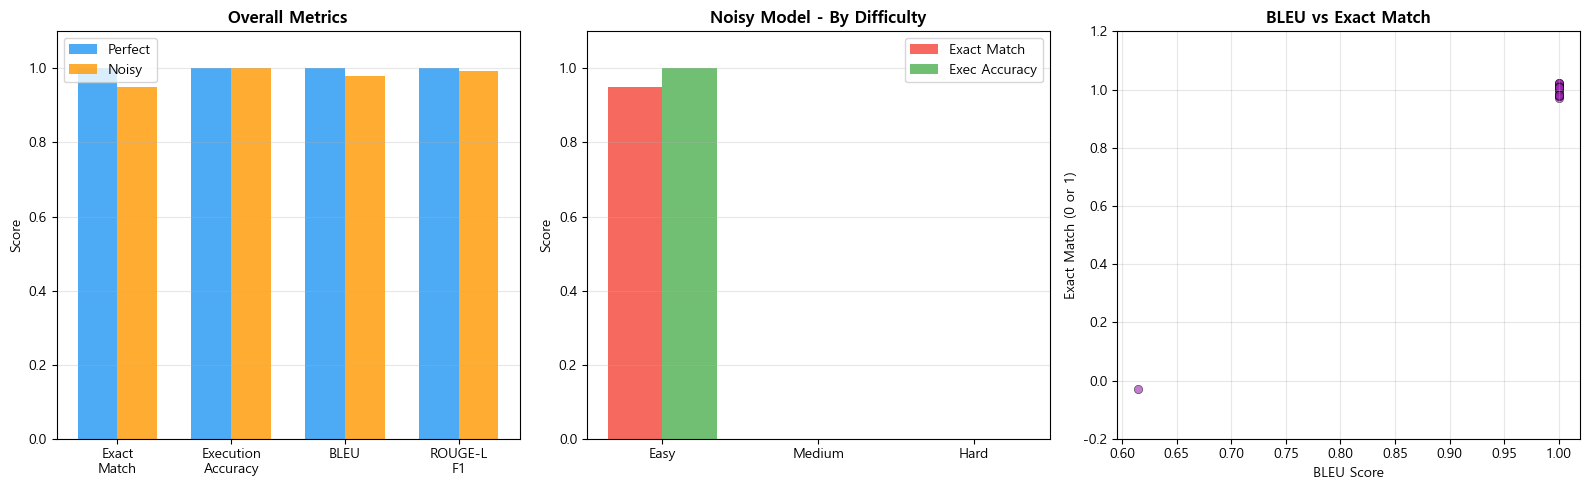

BLEU가 높아도 Exact Match는 0일 수 있다 (대소문자, LIMIT 추가 등)
-> 단일 메트릭에 의존하지 말고 복합 평가를 사용해야 한다


In [15]:
# 평가 결과 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Overall metrics comparison
metrics = ['Exact\nMatch', 'Execution\nAccuracy', 'BLEU', 'ROUGE-L\nF1']
perfect = [perfect_results['exact_match_rate'], perfect_results['execution_accuracy_rate'],
           perfect_results['avg_bleu'], perfect_results['avg_rouge_f1']]
noisy = [noisy_results['exact_match_rate'], noisy_results['execution_accuracy_rate'],
         noisy_results['avg_bleu'], noisy_results['avg_rouge_f1']]

x = np.arange(len(metrics))
width = 0.35
axes[0].bar(x - width/2, perfect, width, label='Perfect', color='#2196F3', alpha=0.8)
axes[0].bar(x + width/2, noisy, width, label='Noisy', color='#FF9800', alpha=0.8)
axes[0].set_ylabel('Score')
axes[0].set_title('Overall Metrics', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].set_ylim(0, 1.1)
axes[0].grid(True, alpha=0.3, axis='y')

# Panel 2: By difficulty
difficulties = ['easy', 'medium', 'hard']
for diff in difficulties:
    if diff not in noisy_results['by_difficulty']:
        noisy_results['by_difficulty'][diff] = {'exact_match_rate': 0, 'execution_accuracy_rate': 0}

noisy_em = [noisy_results['by_difficulty'].get(d, {}).get('exact_match_rate', 0) for d in difficulties]
noisy_ea = [noisy_results['by_difficulty'].get(d, {}).get('execution_accuracy_rate', 0) for d in difficulties]

x2 = np.arange(len(difficulties))
axes[1].bar(x2 - width/2, noisy_em, width, label='Exact Match', color='#F44336', alpha=0.8)
axes[1].bar(x2 + width/2, noisy_ea, width, label='Exec Accuracy', color='#4CAF50', alpha=0.8)
axes[1].set_ylabel('Score')
axes[1].set_title('Noisy Model - By Difficulty', fontsize=12, fontweight='bold')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(['Easy', 'Medium', 'Hard'])
axes[1].legend()
axes[1].set_ylim(0, 1.1)
axes[1].grid(True, alpha=0.3, axis='y')

# Panel 3: Metric correlation scatter
bleu_vals = [d.get('bleu', 0) or 0 for d in noisy_results['details']]
em_vals = [1 if d['exact_match'] else 0 for d in noisy_results['details']]

# Add jitter for visibility
jitter = np.random.normal(0, 0.02, len(em_vals))
axes[2].scatter(bleu_vals, np.array(em_vals) + jitter, alpha=0.6, c='#9C27B0', edgecolors='black', linewidth=0.5)
axes[2].set_xlabel('BLEU Score')
axes[2].set_ylabel('Exact Match (0 or 1)')
axes[2].set_title('BLEU vs Exact Match', fontsize=12, fontweight='bold')
axes[2].set_ylim(-0.2, 1.2)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("BLEU가 높아도 Exact Match는 0일 수 있다 (대소문자, LIMIT 추가 등)")
print("-> 단일 메트릭에 의존하지 말고 복합 평가를 사용해야 한다")

## 7. 핵심 정리

### 이번 노트북에서 배운 것
1. **평가셋 설계**: 난이도 분포 (40/40/20), contamination 방지, 100개 이상
2. **SQL 평가셋**: 4개 테이블, Easy/Medium/Hard 100개 구축
3. **Exact Match vs Execution Accuracy**: EA가 더 실용적 (순서/별칭 무관)
4. **BLEU/ROUGE**: 토큰 겹침 기반, SQL에는 보조 지표로 사용
5. **LLM-as-Judge**: 강력하지만 모델 크기/편향 주의
6. **evaluate_model()**: Phase 8 양자화 검증에 재사용할 통합 함수

### evaluate_model() API
```python
results = evaluate_model(
    model_fn=my_model,       # question -> sql
    eval_data=eval_dataset,  # 100개 평가셋
    db_conn=conn,            # SQLite 연결
)
```

> **핵심 원칙**: 평가셋은 모델보다 오래 살아남는다. 좋은 평가셋 하나가 100번의 학습보다 가치 있다.

In [16]:
# Phase 7-2 체크포인트
checkpoint = {
    "phase": "7-2",
    "title": "커스텀 평가셋 구축",
    "completed": [
        "평가셋 설계 원칙 (대표성, 난이도, 비오염)",
        "Text-to-SQL 100개 평가셋 구축",
        "SQLite 실행 정확도 측정",
        "BLEU / ROUGE-L 직접 구현 및 비교",
        "LLM-as-Judge 프롬프트 설계",
        "evaluate_model() 통합 평가 함수",
    ],
    "next": "Phase 7-3: A/B 테스트와 Human Evaluation",
    "reusable": "evaluate_model() -> Phase 8-1 양자화 검증에 재사용",
}

print("Phase 7-2 체크포인트")
print("=" * 50)
for item in checkpoint["completed"]:
    print(f"  [Done] {item}")
print(f"\n다음: {checkpoint['next']}")
print(f"재사용: {checkpoint['reusable']}")

Phase 7-2 체크포인트
  [Done] 평가셋 설계 원칙 (대표성, 난이도, 비오염)
  [Done] Text-to-SQL 100개 평가셋 구축
  [Done] SQLite 실행 정확도 측정
  [Done] BLEU / ROUGE-L 직접 구현 및 비교
  [Done] LLM-as-Judge 프롬프트 설계
  [Done] evaluate_model() 통합 평가 함수

다음: Phase 7-3: A/B 테스트와 Human Evaluation
재사용: evaluate_model() -> Phase 8-1 양자화 검증에 재사용
